In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, FloatSlider, IntSlider
%matplotlib inline



# Задание 1. Неявный метод Эйлера

Уравнение $\dfrac{du}{dt} = \lambda u$, $u(0) = u_0$.

**Неявная схема Эйлера:**
$$\frac{y_{n+1} - y_n}{\tau} = \lambda y_{n+1} \implies y_{n+1} = \frac{y_n}{1 - \tau\lambda}$$

In [ ]:
def euler_solve(lam, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty(num_steps + 1)
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt * lam * y[k]
    return tt, y


def implicit_euler_solve(lam, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty(num_steps + 1)
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] / (1 - dt * lam)
    return tt, y

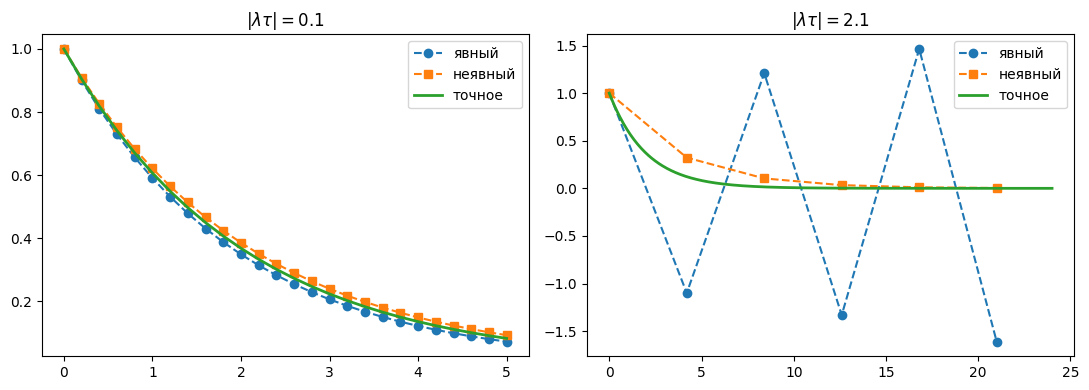

In [ ]:
lam = -0.5

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

dt_small = 0.1 / abs(lam)
tt, y_ex = euler_solve(lam, 1.0, T=5, dt=dt_small)
tt, y_im = implicit_euler_solve(lam, 1.0, T=5, dt=dt_small)
axes[0].plot(tt, y_ex, 'o--', label='явный')
axes[0].plot(tt, y_im, 's--', label='неявный')
axes[0].plot(tt, np.exp(lam * tt), '-', lw=2, label='точное')
axes[0].set_title(f'$|\\lambda\\tau| = {abs(lam)*dt_small:.1f}$')
axes[0].legend()

dt_big = 2.1 / abs(lam)
T_big = 12 / abs(lam)
tt2, y_ex2 = euler_solve(lam, 1.0, T=T_big, dt=dt_big)
tt2, y_im2 = implicit_euler_solve(lam, 1.0, T=T_big, dt=dt_big)
tt_fine = np.linspace(0, T_big, 500)
axes[1].plot(tt2, y_ex2, 'o--', label='явный')
axes[1].plot(tt2, y_im2, 's--', label='неявный')
axes[1].plot(tt_fine, np.exp(lam * tt_fine), '-', lw=2, label='точное')
axes[1].set_title(f'$|\\lambda\\tau| = {abs(lam)*dt_big:.1f}$')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
lam = -0.5
tt, y = implicit_euler_solve(lam, u0=1.0, T=8/abs(lam), dt=2.1/abs(lam))
assert (y > 0).all()

---
# Задание 2. Явная схема Эйлера и матричная экспонента

Система $\dfrac{d\mathbf{u}}{dt} = A\mathbf{u}$, где $A$ — постоянная матрица $2\times 2$.

In [5]:
def euler_solve2(a, u0, T, dt):
    
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    ndim = a.shape[0]
    y = np.empty((num_steps + 1, ndim))
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt * a @ y[k]
    return tt, y


def mat_exp_solve(a, u0, tt):

    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    result = np.array([expm(t * a) @ u0 for t in tt])
    return result

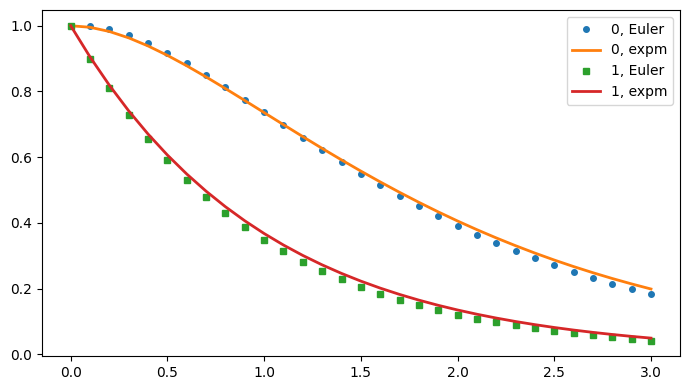

max |Euler - expm| = 1.9201e-02


In [6]:
a = np.array([[-1, 1],
              [ 0,-1]], dtype=float)
u0 = [1, 1]

t, y  = euler_solve2(a, u0, T=3, dt=0.1)
ym = mat_exp_solve(a, u0, t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, y[:, 0],  'o', ms=4, label='0, Euler')
ax.plot(t, ym[:, 0], '-', lw=2, label='0, expm')
ax.plot(t, y[:, 1],  's', ms=4, label='1, Euler')
ax.plot(t, ym[:, 1], '-', lw=2, label='1, expm')
ax.legend()
plt.tight_layout()
plt.show()

print(f"max |Euler - expm| = {np.max(np.abs(y - ym)):.4e}")

---
# Задание 3. Проверка жёсткости системы и неявные методы

Матрица правой части:
$$A = \begin{pmatrix} -10 & 10 \\ 32 & -499 \end{pmatrix}, \quad u(0) = (1, 0)^\top$$

In [7]:
A3 = np.array([[-10, 10],
               [ 32,-499]], dtype=float)
u0_3 = np.array([1.0, 0.0])

eigvals = np.linalg.eigvals(A3)
print("Собственные значения:", eigvals)
s = np.max(np.abs(eigvals.real)) / np.min(np.abs(eigvals.real))
print(f"Число жёсткости s = {s:.1f}")

Собственные значения: [  -9.34647667 -499.65352333]
Число жёсткости s = 53.5


In [8]:
lam_max = np.max(np.abs(eigvals.real))
tau_crit = 2.0 / lam_max
print(f"Критический шаг (явный Эйлер): tau_crit = {tau_crit:.4f}")
print(f"При tau = 0.01: |lambda_max*tau| = {lam_max * 0.01:.2f} ({'стабилен' if lam_max*0.01<=2 else 'нестабилен'})")

Критический шаг (явный Эйлер): tau_crit = 0.0040
При tau = 0.01: |lambda_max*tau| = 5.00 (нестабилен)


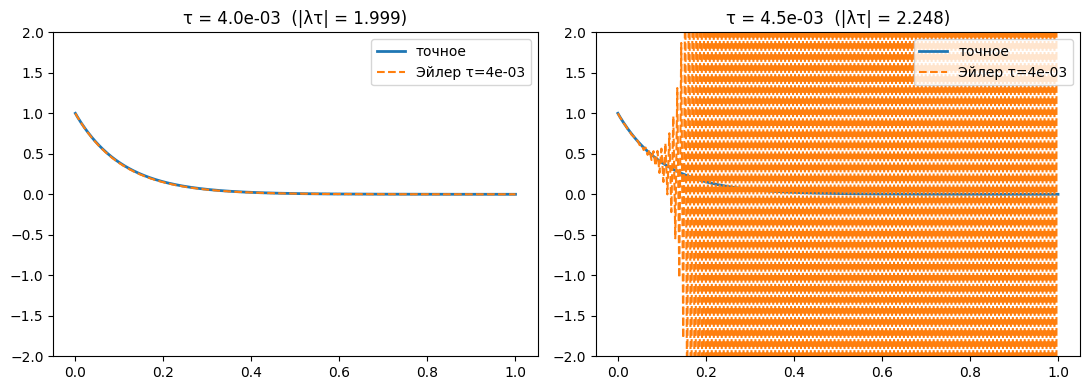

In [9]:
T3 = 1.0
tt_ref = np.linspace(0, T3, 500)
y_ref = mat_exp_solve(A3, u0_3, tt_ref)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for tau, ax in zip([4e-3, 4.5e-3], axes):
    tt, y_euler = euler_solve2(A3, u0_3, T=T3, dt=tau)
    ym = mat_exp_solve(A3, u0_3, tt)
    ax.plot(tt_ref, y_ref[:, 0], '-', lw=2, label='точное')
    ax.plot(tt, y_euler[:, 0], '--', label=f'Эйлер τ={tau:.0e}')
    ax.set_title(f'τ = {tau:.1e}  (|λτ| = {lam_max*tau:.3f})')
    ax.set_ylim(-2, 2)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
def implicit_euler_solve2(a, u0, T, dt):
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    ndim = a.shape[0]
    y = np.empty((num_steps + 1, ndim))
    y[0] = u0
    M = np.eye(ndim) - dt * a
    for k in range(num_steps):
        y[k+1] = np.linalg.solve(M, y[k])
    return tt, y

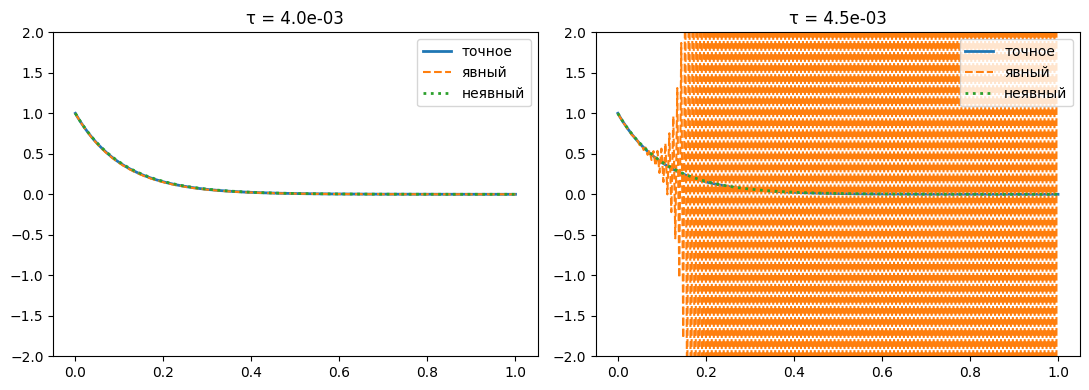

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for tau, ax in zip([4e-3, 4.5e-3], axes):
    tt, y_ex = euler_solve2(A3, u0_3, T=T3, dt=tau)
    tt, y_im = implicit_euler_solve2(A3, u0_3, T=T3, dt=tau)
    ax.plot(tt_ref, y_ref[:, 0], '-', lw=2, label='точное')
    ax.plot(tt, y_ex[:, 0], '--', label='явный')
    ax.plot(tt, y_im[:, 0], ':', lw=2, label='неявный')
    ax.set_title(f'τ = {tau:.1e}')
    ax.set_ylim(-2, 2)
    ax.legend()

plt.tight_layout()
plt.show()

---
# Задание 6. Законы сохранения и решение ОДУ

Уравнение маятника: $\dfrac{d^2 u}{dt^2} + \omega^2 u = 0$.

Приведение к системе первого порядка: $p = u,\ q = du/dt$:
$$\frac{dp}{dt} = q, \quad \frac{dq}{dt} = -\omega^2 p$$

Закон сохранения энергии: $E = \dfrac{q^2}{2} + \dfrac{\omega^2 p^2}{2} = \text{const}$.

In [ ]:
omega = 1.0
T_osc = 10 * (2 * np.pi / omega) 
u0_osc = np.array([1.0, 0.0])     

A_osc = np.array([[0, 1],
                  [-omega**2, 0]], dtype=float)

def energy(y, omega):
    """E = q^2/2 + omega^2*p^2/2; y shape (n, 2)."""
    return 0.5 * y[:, 1]**2 + 0.5 * omega**2 * y[:, 0]**2

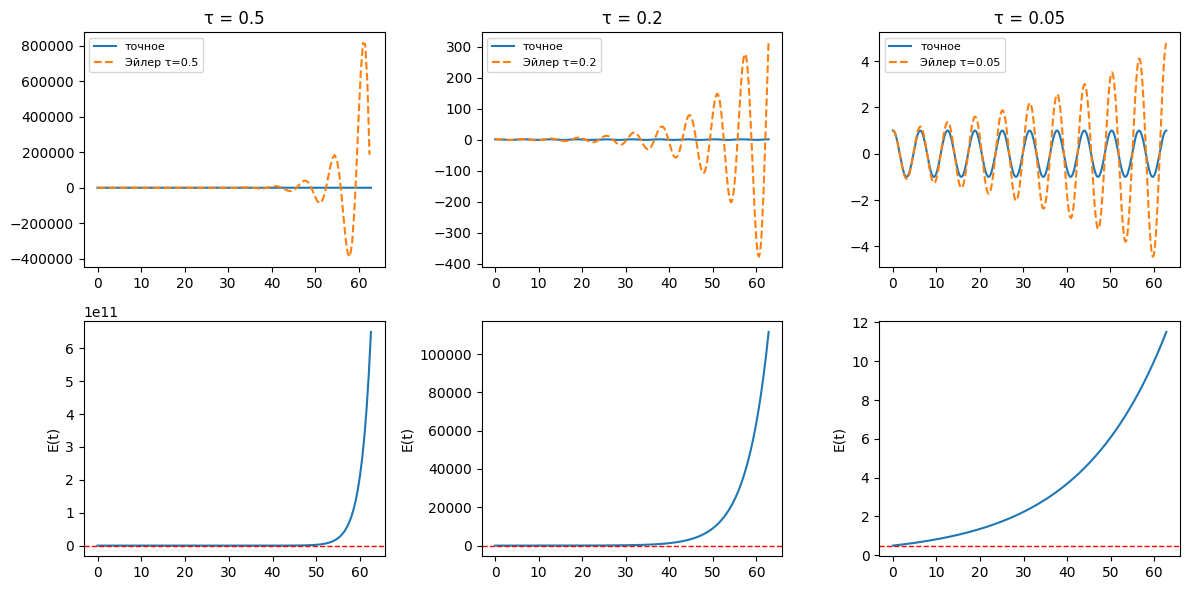

In [ ]:
taus = [0.5, 0.2, 0.05]

fig, axes = plt.subplots(2, len(taus), figsize=(12, 6))

tt_ref = np.linspace(0, T_osc, 2000)
y_ref = mat_exp_solve(A_osc, u0_osc, tt_ref)

for j, tau in enumerate(taus):
    tt, y = euler_solve2(A_osc, u0_osc, T=T_osc, dt=tau)
    E = energy(y, omega)
    axes[0, j].plot(tt_ref, y_ref[:, 0], '-', lw=1.5, label='точное')
    axes[0, j].plot(tt, y[:, 0], '--', label=f'Эйлер τ={tau}')
    axes[0, j].set_title(f'τ = {tau}')
    axes[0, j].legend(fontsize=8)
    axes[1, j].plot(tt, E)
    axes[1, j].axhline(E[0], color='r', lw=1, linestyle='--')
    axes[1, j].set_ylabel('E(t)')

plt.tight_layout()
plt.show()

In [ ]:
def rk2_solve(A, u0, T, dt):
    A = np.asarray(A, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty((num_steps + 1, len(u0)))
    y[0] = u0
    for k in range(num_steps):
        k1 = A @ y[k]
        k2 = A @ (y[k] + dt * k1)
        y[k+1] = y[k] + dt * 0.5 * (k1 + k2)
    return tt, y

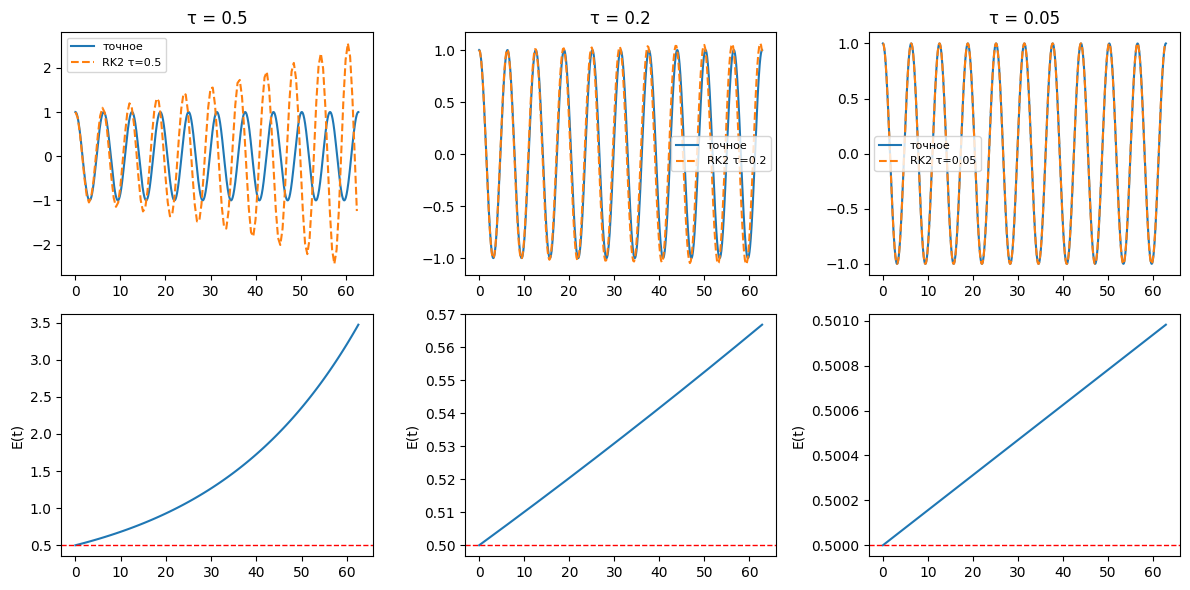

In [25]:
fig, axes = plt.subplots(2, len(taus), figsize=(12, 6))

for j, tau in enumerate(taus):
    tt, y = rk2_solve(A_osc, u0_osc, T=T_osc, dt=tau)
    E = energy(y, omega)
    axes[0, j].plot(tt_ref, y_ref[:, 0], '-', lw=1.5, label='точное')
    axes[0, j].plot(tt, y[:, 0], '--', label=f'RK2 τ={tau}')
    axes[0, j].set_title(f'τ = {tau}')
    axes[0, j].legend(fontsize=8)
    axes[1, j].plot(tt, E)
    axes[1, j].axhline(E[0], color='r', lw=1, linestyle='--')
    axes[1, j].set_ylabel('E(t)')

plt.tight_layout()
plt.show()

In [ ]:
def predictor_corrector_solve(omega, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty((num_steps + 1, 2))
    y[0] = u0
    E0 = 0.5 * u0[1]**2 + 0.5 * omega**2 * u0[0]**2
    A = np.array([[0, 1], [-omega**2, 0]], dtype=float)
    for k in range(num_steps):
        y_pred = y[k] + dt * A @ y[k]
        E_pred = 0.5 * y_pred[1]**2 + 0.5 * omega**2 * y_pred[0]**2
        scale = np.sqrt(E0 / E_pred)
        y[k+1] = scale * y_pred
    return tt, y

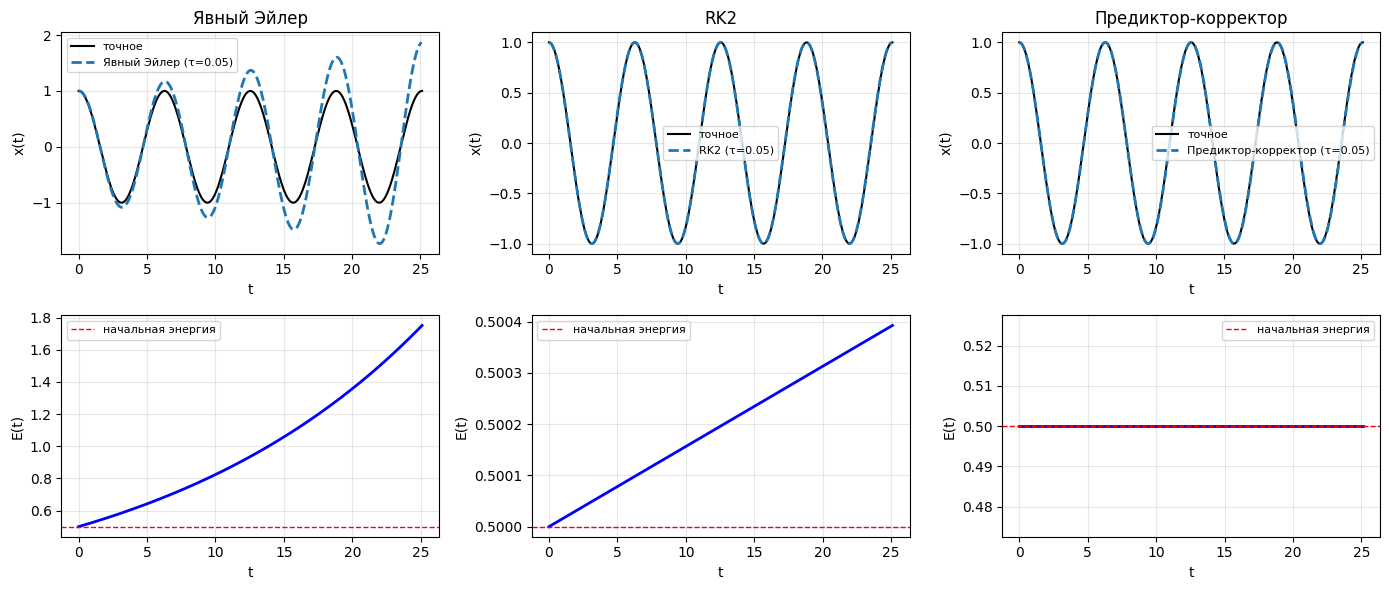

In [ ]:
omega = 1.0               
u0_osc = np.array([1.0, 0.0])
T_osc = 4 * (2 * np.pi / omega)
tau = 0.05                    

tt_ref = np.linspace(0, T_osc, 1000)
x_ref = np.cos(omega * tt_ref)          
v_ref = -omega * np.sin(omega * tt_ref) 
y_ref = np.column_stack((x_ref, v_ref))

tt_e, y_euler = euler_solve2(np.array([[0,1],[-omega**2,0]]), u0_osc, T_osc, tau)
tt_rk, y_rk2   = rk2_solve(np.array([[0,1],[-omega**2,0]]), u0_osc, T_osc, tau)
tt_pc, y_pc   = predictor_corrector_solve(omega, u0_osc, T_osc, tau)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

methods = [
    ('Явный Эйлер', tt_e, y_euler),
    ('RK2', tt_rk, y_rk2),
    ('Предиктор-корректор', tt_pc, y_pc)
]

for j, (name, tt, y) in enumerate(methods):
    ax_top = axes[0, j]
    ax_top.plot(tt_ref, y_ref[:, 0], '-', lw=1.5, label='точное', color='black')
    ax_top.plot(tt, y[:, 0], '--', lw=2, label=f'{name} (τ={tau})')
    ax_top.set_title(name)
    ax_top.set_xlabel('t')
    ax_top.set_ylabel('x(t)')
    ax_top.legend(fontsize=8)
    ax_top.grid(True, alpha=0.3)

    ax_bot = axes[1, j]
    E = energy(y, omega)
    ax_bot.plot(tt, E, 'b-', lw=2)
    ax_bot.axhline(E[0], color='r', lw=1, linestyle='--', label='начальная энергия')
    ax_bot.set_xlabel('t')
    ax_bot.set_ylabel('E(t)')
    ax_bot.legend(fontsize=8)
    ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Задание 7. Методы предиктора и корректора для ОДУ

То же уравнение маятника. Используем `scipy.integrate.solve_ivp`, метод прогноза-коррекции Адамса и метод Милна.

In [38]:
def pendulum_rhs(t, y, omega=1.0):
    return [y[1], -omega**2 * y[0]]


def adams_pc_solve(f, u0, T, dt, omega=1.0):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    dim = len(u0)
    y = np.empty((num_steps + 1, dim))
    y[0] = u0

    for k in range(min(3, num_steps)):
        yk = y[k]
        k1 = np.array(f(tt[k],          yk,             omega))
        k2 = np.array(f(tt[k] + dt/2,   yk + dt/2 * k1, omega))
        k3 = np.array(f(tt[k] + dt/2,   yk + dt/2 * k2, omega))
        k4 = np.array(f(tt[k] + dt,     yk + dt   * k3, omega))
        y[k+1] = yk + dt / 6 * (k1 + 2*k2 + 2*k3 + k4)

    fs = [np.array(f(tt[k], y[k], omega)) for k in range(4)]

    for i in range(3, num_steps):
        
        y_pred = y[i] + dt/24 * (-9*fs[0] + 37*fs[1] - 59*fs[2] + 55*fs[3])
        f_pred = np.array(f(tt[i+1], y_pred, omega))
        
        y[i+1] = y[i] + dt/24 * (fs[1] - 5*fs[2] + 19*fs[3] + 9*f_pred)
        fs = [fs[1], fs[2], fs[3], np.array(f(tt[i+1], y[i+1], omega))]

    return tt, y


def milne_solve(f, u0, T, dt, omega=1.0):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    dim = len(u0)
    y = np.empty((num_steps + 1, dim))
    y[0] = u0

    for k in range(min(3, num_steps)):
        yk = y[k]
        k1 = np.array(f(tt[k],          yk,             omega))
        k2 = np.array(f(tt[k] + dt/2,   yk + dt/2 * k1, omega))
        k3 = np.array(f(tt[k] + dt/2,   yk + dt/2 * k2, omega))
        k4 = np.array(f(tt[k] + dt,     yk + dt   * k3, omega))
        y[k+1] = yk + dt / 6 * (k1 + 2*k2 + 2*k3 + k4)

    fs = [np.array(f(tt[k], y[k], omega)) for k in range(4)]

    for i in range(3, num_steps):
        y_pred = y[i-3] + 4*dt/3 * (2*fs[1] - fs[2] + 2*fs[3])
        f_pred = np.array(f(tt[i+1], y_pred, omega))
        y[i+1] = y[i-1] + dt/3 * (fs[2] + 4*fs[3] + f_pred)
        fs = [fs[1], fs[2], fs[3], np.array(f(tt[i+1], y[i+1], omega))]

    return tt, y

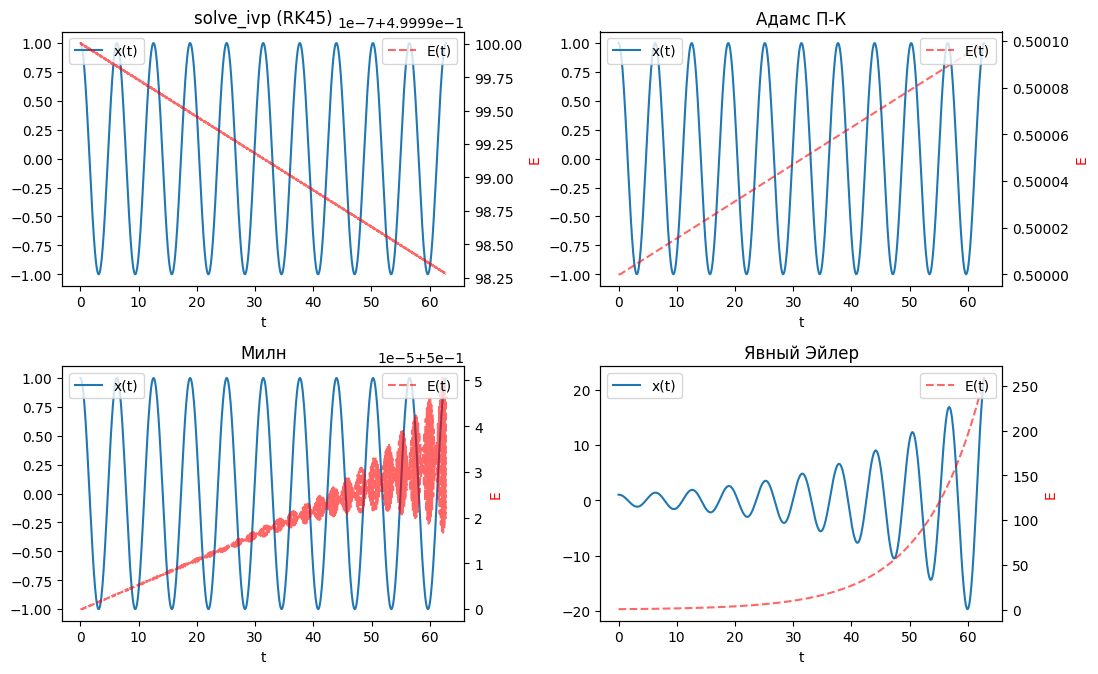

In [39]:
omega = 1.0
T_osc = 10 * (2 * np.pi / omega)
u0_osc = [1.0, 0.0]
tau = 0.1

sol = solve_ivp(pendulum_rhs, [0, T_osc], u0_osc,
                method='RK45', max_step=tau,
                args=(omega,), dense_output=True)
tt_ref = np.linspace(0, T_osc, 2000)
y_ivp = sol.sol(tt_ref).T

tt_a, y_adams = adams_pc_solve(pendulum_rhs, u0_osc, T=T_osc, dt=tau)
tt_m, y_milne = milne_solve(pendulum_rhs, u0_osc, T=T_osc, dt=tau)
tt_r, y_rk2   = rk2_solve(A_osc, np.array(u0_osc), T=T_osc, dt=tau)

def euler_solve2(A, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    ndim = A.shape[0]
    y = np.empty((num_steps + 1, ndim))
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt * (A @ y[k])
    return tt, y

A_osc = np.array([[0, 1], [-omega**2, 0]])

tt_e, y_euler = euler_solve2(A_osc, np.array(u0_osc), T=T_osc, dt=tau)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

methods_data = [
    (tt_ref, y_ivp, 'solve_ivp (RK45)'),
    (tt_a, y_adams, 'Адамс П-К'),
    (tt_m, y_milne, 'Милн'),
    (tt_e, y_euler, 'Явный Эйлер')
]

for ax, (tt, y, label) in zip(axes.flat, methods_data):
    ax.plot(tt, y[:, 0], label='x(t)')
    E = energy(np.array(y), omega)
    ax2 = ax.twinx()
    ax2.plot(tt, E, 'r--', alpha=0.6, label='E(t)')
    ax2.set_ylabel('E', color='r')
    ax.set_title(label)
    ax.set_xlabel('t')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
# Задание 8. Нелинейное уравнение Пуассона

$$\phi''(x) = e^{\phi(x)} - n(x), \quad n(x) = 1 + e^{-3(x-5)^2},$$
$$\phi(0) = 0, \quad \phi'(0) = 0, \quad 0 \le x \le 10.$$

Приводим к системе первого порядка: $p = \phi$, $q = \phi'$:
$$p' = q, \quad q' = e^{p} - n(x).$$

In [ ]:
def n_func(x):
    return 1.0 + np.exp(-3 * (x - 5)**2)


def poisson_rhs(x, y):
    p, q = y
    return [q, np.exp(p) - n_func(x)]

sol = solve_ivp(poisson_rhs, [0, 10], [0.0, 0.0],
                method='RK45', max_step=0.01, dense_output=True)

xx = np.linspace(0, 10, 1000)
phi_num = sol.sol(xx)[0]

print(f"phi(10) = {sol.sol(10)[0]:.6f}")

phi(10) = -14.749154


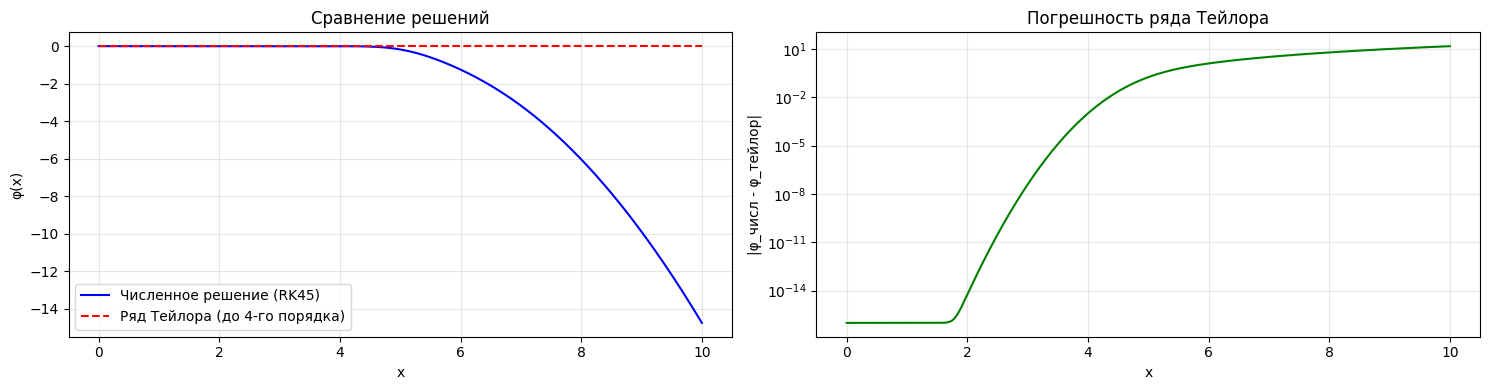

In [ ]:
# Аналитическое решение рядом Тейлора (разложение вблизи x=0)
# phi(0)=0, phi'(0)=0 => phi'' = e^0 - n(0) = 1 - (1 + e^0) = -e^0 = -(1+1) = -1 - e^0
# n(0) = 1 + exp(-3*25) ≈ 1 (очень мало exp(-75))
# phi''(0) = e^0 - n(0) ≈ 1 - 1 = 0  (т.к. n(0) ≈ 1)
# Используем ряд Тейлора до 4-го порядка

# phi = a0 + a1*x + a2*x^2/2 + a3*x^3/6 + a4*x^4/24 + ...
# phi(0)=0 => a0=0
# phi'(0)=0 => a1=0
# phi''(0) = exp(phi(0)) - n(0) = 1 - n(0)
n0 = n_func(0.0)
phi0 = 0.0
dphi0 = 0.0

# n(x) = 1 + exp(-3(x-5)^2)
n0 = n_func(0.0)                      # ≈ 1 + exp(-75) ≈ 1
dn0 = -6.0 * (0.0 - 5.0) * np.exp(-3.0*(0.0-5.0)**2)  # производная n'(x) в 0
d2n0 = (36.0*(0.0-5.0)**2 - 6.0) * np.exp(-3.0*(0.0-5.0)**2)  # вторая производная

# Производные φ в нуле
d2phi0 = np.exp(phi0) - n0           # φ''(0)
d3phi0 = np.exp(phi0) * dphi0 - dn0  # φ'''(0) = (exp(φ) φ' - n')
d4phi0 = np.exp(phi0)*(dphi0**2 + d2phi0) - d2n0  # φ''''(0)

# Ряд Тейлора: φ(x) ≈ φ(0) + φ'(0)x + φ''(0)x²/2! + φ'''(0)x³/3! + φ''''(0)x⁴/4!
def phi_taylor(x):
    return (phi0
            + dphi0 * x
            + d2phi0 * x**2 / 2.0
            + d3phi0 * x**3 / 6.0
            + d4phi0 * x**4 / 24.0)

phi_tay = phi_taylor(xx)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. Сравнение решений
axes[0].plot(xx, phi_num, 'b-', lw=1.5, label='Численное решение (RK45)')
axes[0].plot(xx, phi_tay, 'r--', lw=1.5, label='Ряд Тейлора (до 4-го порядка)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('φ(x)')
axes[0].set_title('Сравнение решений')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Погрешность ряда Тейлора (логарифмическая шкала)
error = np.abs(phi_num - phi_tay) + 1e-16  # +1e-16 для избежания log(0)
axes[1].semilogy(xx, error, 'g-', lw=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('|φ_числ - φ_тейлор|')
axes[1].set_title('Погрешность ряда Тейлора')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

---
# Задание 9. Построение интерфейса и фазовые портреты

Параметризуем начальное условие $\phi'(0) = s$ и строим интерфейс.  
Методом стрельбы находим $s^*$ такое, что $\phi(10) = 0$.


In [40]:
def solve_poisson(s):
    """Решает уравнение Пуассона с phi(0)=0, phi'(0)=s."""
    sol = solve_ivp(poisson_rhs, [0, 10], [0.0, s],
                    method='RK45', max_step=0.01, dense_output=True)
    return sol


def phi_at_10(s):
    return solve_poisson(s).sol(10)[0]


# Поиск s* такого, что phi(10) = 0
s_star = brentq(phi_at_10, -5.0, 5.0)
print(f"phi'(0) = {s_star:.6f}  =>  phi(10) = {phi_at_10(s_star):.2e}")

phi'(0) = 0.006518  =>  phi(10) = -1.20e-14


In [ ]:
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from ipywidgets import widgets


def main(*args):
    s = w_s.value
    sol = solve_poisson(s)
    xx = np.linspace(0, 10, 500)
    phi = sol.sol(xx)[0]
    dphi = sol.sol(xx)[1]

    with out2:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7))

        ax1.plot(xx, phi, 'k-', lw=2, label=f"φ(x), s={s:.2f}")
        ax1.axhline(0, color='gray', lw=0.7, ls='--')
        ax1.set_xlabel('x')
        ax1.set_ylabel('φ')
        ax1.set_title(f"φ(10) = {phi[-1]:.4f}")
        ax1.legend()

        ax2.plot(phi, dphi, 'k-', lw=2, label="фазовый портрет")
        ax2.set_xlabel('φ')
        ax2.set_ylabel("φ'")
        ax2.set_title('Фазовый портрет')
        ax2.legend()

        plt.tight_layout()
        plt.show()

# Виджеты
out1 = widgets.Output(layout={'width': '30%'})
out2 = widgets.Output(layout={'width': '70%'})

w_s = widgets.FloatSlider(description="φ'(0) ", min=-5.0, max=5.0, step=0.05, value=0.0)
w_button = widgets.Button(description='Запустить', button_style='primary')
w_button.on_click(main)

display(widgets.HBox([out1, out2]))
with out1:
    display(w_s, w_button)

φ'(0) = 0.006518  =>  φ(10) = -1.20e-14


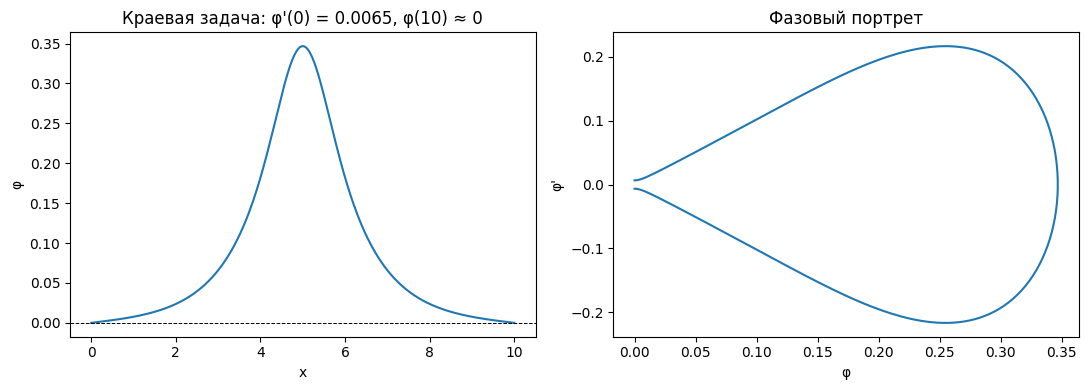

In [51]:
sol_star = solve_poisson(s_star)
xx = np.linspace(0, 10, 500)
phi_star = sol_star.sol(xx)[0]
dphi_star = sol_star.sol(xx)[1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(xx, phi_star)
axes[0].axhline(0, color='k', lw=0.7, ls='--')
axes[0].set_xlabel('x')
axes[0].set_ylabel('φ')
axes[0].set_title(f"Краевая задача: φ'(0) = {s_star:.4f}, φ(10) ≈ 0")

axes[1].plot(phi_star, dphi_star)
axes[1].set_xlabel('φ')
axes[1].set_ylabel("φ'")
axes[1].set_title('Фазовый портрет')

plt.tight_layout()
plt.show()

---
# Задание 10. Построение интерфейса и фазовые портреты-2

Уравнение нелинейного осциллятора:
$$\frac{d^2 y}{dt^2} = -\omega^2 y - \beta y^3, \quad y(0) = q,\ \dot{y}(0) = r$$

Приводим к системе: $u_1 = y$, $u_2 = \dot{y}$:
$$\dot{u}_1 = u_2, \quad \dot{u}_2 = -\omega^2 u_1 - \beta u_1^3$$

In [ ]:
def duffing_rhs(t, u, omega, beta):
    y, v = u
    return [v, -omega**2 * y - beta * y**3]


def solve_duffing(omega, beta, q, r, T_max, n_steps):
    dt = T_max / n_steps
    sol = solve_ivp(duffing_rhs, [0, T_max], [q, r],
                    method='RK45', max_step=dt,
                    args=(omega, beta), dense_output=True)
    tt = np.linspace(0, T_max, 2000)
    y_sol = sol.sol(tt)
    return tt, y_sol[0], y_sol[1]


def plot_duffing(omega=1.0, beta=0.1, q=1.0, r=0.0, T_max=40.0, n_steps=4000):
    tt, y, v = solve_duffing(omega, beta, q, r, T_max, n_steps)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(tt, y)
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('y(t)')
    axes[0].set_title(f'ω={omega}, β={beta}, q={q}, r={r}')

    axes[1].plot(tt, v)
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('dy/dt')

    axes[2].plot(y, v, lw=0.8)
    axes[2].set_xlabel('y')
    axes[2].set_ylabel('dy/dt')
    axes[2].set_title('Фазовый портрет')

    plt.tight_layout()
    plt.show()


# Интерактивный интерфейс
interact(plot_duffing,
         omega=FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1,  description='ω',      continuous_update=False),
         beta= FloatSlider(value=0.1, min=-2.0, max=2.0, step=0.05, description='β',      continuous_update=False),
         q=    FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.1,  description='q=y(0)', continuous_update=False),
         r=    FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1,  description='r=v(0)', continuous_update=False),
         T_max=FloatSlider(value=40., min=5.0,  max=200., step=5.,  description='T_max',  continuous_update=False),
         n_steps=IntSlider(value=4000, min=100, max=20000, step=100, description='steps', continuous_update=False))

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='ω', max=3.0, min=0.1), Floa…

<function __main__.plot_duffing(omega=1.0, beta=0.1, q=1.0, r=0.0, T_max=40.0, n_steps=4000)>

---
# Задание 11. Движение планет вокруг Солнца

В безразмерных единицах ($x_0$ — единица длины, $(GM/x_0^3)^{-1/2}$ — единица времени):
$$\ddot{x} = -\frac{x}{r^3}, \quad \ddot{y} = -\frac{y}{r^3}, \quad r = \sqrt{x^2 + y^2}$$
Начальные условия: $x(0) = 1,\ y(0) = 0,\ v_x(0) = 0,\ v_y(0) = V_0$.

Эксцентриситет $e = |p - 1|$, где $p$ — значение $y$ при $y = 0$ (второй проход).  
Большая полуось $a = (1 + |x_{\min}|)/2$, период $T = 2 t_M$.  
Третий закон Кеплера: $K_3 = T^2 / a^3 = \text{const}$.

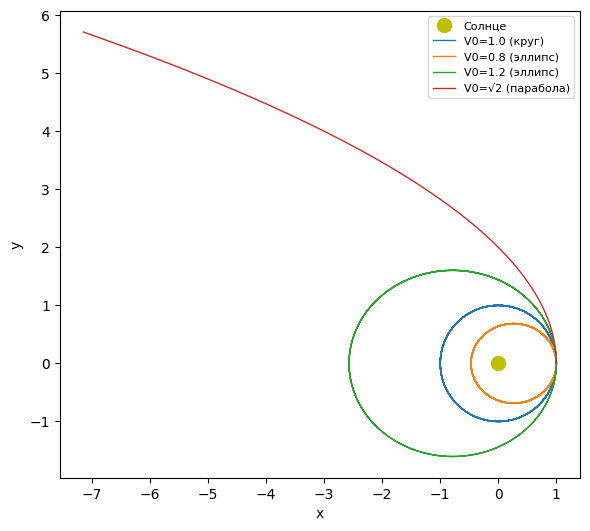

In [55]:
def orbit_rhs(t, u):
    x, y, vx, vy = u
    r3 = (x**2 + y**2)**1.5
    return [vx, vy, -x / r3, -y / r3]


def solve_orbit(V0, T_max=20.0, dt=1e-3):
    sol = solve_ivp(orbit_rhs, [0, T_max], [1.0, 0.0, 0.0, V0],
                    method='RK45', max_step=dt, dense_output=True)
    tt = np.linspace(0, T_max, int(T_max / dt))
    state = sol.sol(tt)
    x, y, vx, vy = state
    return tt, x, y, vx, vy


# Несколько значений V0: круговая, эллиптические, параболическая
V0_list = [1.0, 0.8, 1.2, np.sqrt(2)]
labels  = ['V0=1.0 (круг)', 'V0=0.8 (эллипс)', 'V0=1.2 (эллипс)', 'V0=√2 (парабола)']

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(0, 0, 'yo', ms=10, zorder=5, label='Солнце')

for V0, label in zip(V0_list, labels):
    T_max = 40 if V0 < np.sqrt(2) else 15
    tt, x, y, vx, vy = solve_orbit(V0, T_max=T_max)
    ax.plot(x, y, lw=1, label=label)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [61]:
def kepler_analysis(V0, T_max=100, dt=5e-4):
    tt, x, y, vx, vy = solve_orbit(V0, T_max=T_max, dt=dt)
    
    # Ищем пересечение y=0 сверху вниз (апогей), начиная с t>0
    crossings = np.where((y[:-1] > 0) & (y[1:] <= 0))[0]
    if len(crossings) == 0:
        return None
    i_M = crossings[0]          # первый апогей
    t_M = tt[i_M]
    T = 2 * t_M                 # полный период
    
    r_ap = np.sqrt(x[i_M]**2 + y[i_M]**2)   # расстояние в апогее
    r_per = 1.0                # стартовое расстояние (перигелий, т.к. vy>0, vx=0)
    a = (r_per + r_ap) / 2
    e = (r_ap - r_per) / (r_ap + r_per)
    K3 = T**2 / a**3
    return {'V0': V0, 'T': T, 'a': a, 'e': e, 'K3': K3}


print(f"{'V0':>6}  {'T':>8}  {'a':>8}  {'e':>8}  {'K3=T²/a³':>10}")
for V0 in [0.6, 0.8, 1.0, 1.1, 1.2]:
    res = kepler_analysis(V0)
    if res:
        print(f"{res['V0']:>6.1f}  {res['T']:>8.4f}  {res['a']:>8.4f}  {res['e']:>8.4f}  {res['K3']:>10.4f}")

    V0         T         a         e    K3=T²/a³
   0.6    2.9910    0.6098   -0.6400     39.4610
   0.8    3.9610    0.7353   -0.3600     39.4667
   1.0    6.2830    1.0000   -0.0000     39.4765
   1.1    8.9480    1.2658    0.2100     39.4764
   1.2   14.9931    1.7857    0.4400     39.4771


In [57]:
# Второй закон Кеплера: равные площади за равные времена
V0 = 0.8
tt, x, y, vx, vy = solve_orbit(V0, T_max=30, dt=5e-4)
dt_arr = np.diff(tt)

# Площадь, заметаемая за шаг: dS = 0.5 * |r x v| * dt
dS = 0.5 * np.abs(x[:-1] * vy[:-1] - y[:-1] * vx[:-1]) * dt_arr

# Площадь за равные промежутки времени (10 участков)
n_seg = 10
seg_len = len(dS) // n_seg
areas = [dS[i*seg_len:(i+1)*seg_len].sum() for i in range(n_seg)]
print("Площади за 10 равных интервалов:")
for i, S in enumerate(areas):
    print(f"  сегмент {i+1}: S = {S:.5f}")
print(f"\nОтносительный разброс: {np.std(areas)/np.mean(areas)*100:.3f}%")

Площади за 10 равных интервалов:
  сегмент 1: S = 1.19982
  сегмент 2: S = 1.19982
  сегмент 3: S = 1.19982
  сегмент 4: S = 1.19982
  сегмент 5: S = 1.19982
  сегмент 6: S = 1.19982
  сегмент 7: S = 1.19982
  сегмент 8: S = 1.19982
  сегмент 9: S = 1.19982
  сегмент 10: S = 1.19982

Относительный разброс: 0.000%


E(0) = -0.680000,  max|E - E(0)| = 1.69e-14


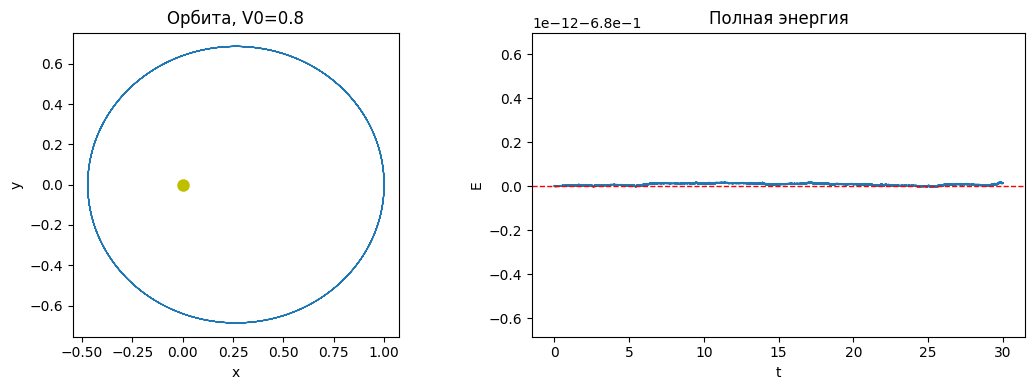

In [58]:
# Сохранение полной механической энергии E = v^2/2 - 1/r
V0 = 0.8
tt, x, y, vx, vy = solve_orbit(V0, T_max=30, dt=5e-4)

r  = np.sqrt(x**2 + y**2)
E  = 0.5 * (vx**2 + vy**2) - 1.0 / r

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x, y, lw=0.8)
axes[0].plot(0, 0, 'yo', ms=8)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Орбита, V0={V0}')

axes[1].plot(tt, E)
axes[1].axhline(E[0], color='r', lw=1, ls='--')
axes[1].set_xlabel('t')
axes[1].set_ylabel('E')
axes[1].set_title('Полная энергия')

print(f"E(0) = {E[0]:.6f},  max|E - E(0)| = {np.max(np.abs(E - E[0])):.2e}")

plt.tight_layout()
plt.show()

In [59]:
# Анимация орбиты
V0 = 0.8
tt, x, y, vx, vy = solve_orbit(V0, T_max=10, dt=1e-3)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(0, 0, 'yo', ms=10, zorder=5)
ax.set_xlim(-2, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')

trail, = ax.plot([], [], 'b-', lw=0.8, alpha=0.5)
body,  = ax.plot([], [], 'bo', ms=7)

stride = 20
frames = range(0, len(tt), stride)

def init():
    trail.set_data([], [])
    body.set_data([], [])
    return trail, body

def update(i):
    trail.set_data(x[max(0, i-300):i], y[max(0, i-300):i])
    body.set_data([x[i]], [y[i]])
    return trail, body

anim_orbit = FuncAnimation(fig, update, frames=frames, init_func=init,
                            interval=20, blit=True)
plt.close()
anim_orbit